# Periodic versus Pulse 

What I have done is rerun the original ones which were just the pulses and now we are seeing what has happened. But what happens, i think, is that we don't loop through it enough, because if we loop through it enough, we eventually get the periodic signal coming back through. 

can considering just running the period bls, once we are above a certain SNR, we should pull the periodic bls return instead.
the hybrid approach is new, so run with and without the pulses to make a better comparison.
look at this by breaking down the tests into manageable cases, e.g. periodic bls versus tls, then turn on the pulse search part
where does it make things better and where does it make it worse?
the shape we are testing versus the reality of the actual shape.

use a branch of the code (some functionality of git, i think) so that i can tinker with it without any consequence. 


basicially, i reran everything that was pulse only.

In [3]:
import os
import numpy as np
import pandas as pd

homedir = os.getcwd()
import pytfit5.bls_cpu as gbls
import pytfit5.pipefuncs as pipe
import pytfit5.transitPy5 as tpy5

what might be useful is visualising what is pulse and what is periodic.

all pulse and then all periodic
all periodic and then all pulse
mixed
only pulse
only periodic

and then we can do the ratio for pulse first and periodic first?


## Running BLS Pulse versus Periodic BLS
a case study we want to look at is where bls just runs the pulse but tls finds the periodic signal. and then we want to determine if the periodic bls can do that too.

if periodic bls can do that, then that means that the weighing of the pulse versus bls is not quite great? would the best case to be to run the pulse and then run bls? bc lowkey both sets of data are saved and run, it's just the comparison which is a pain in the butt, so what we can do is we can save the alternative. 

In [27]:
# Getting the recovery of what was only run as the pulse.
pcat = pd.read_csv(pipe.datadir('planet_cat.csv'))
bdf = pd.read_csv(pipe.datadir('output/periodic_bls.csv'))
rics = np.unique(bdf.RIC)
cat = pcat.copy()[np.isin(pcat.star_id, rics)]
rois = np.array(cat.planet_id)
cat['star_rho'] = pipe.rho(cat.star_mass, cat.star_radius)

# Some of the depths are negative, so an easy fix is just to make them positive
bdf.TDepth = np.abs(bdf.TDepth)
brec = cat.groupby('planet_id')[cat.columns].apply(pipe.roirec, rundf=bdf)
brec.set_index(brec.index.get_level_values(0), inplace=True)
brec.head()

,Period,T0,TDur,TDepth,SNR,overlap_fraction,precision,true_positive,false_positive,false_negative,period_factor,period_factor_type,is_recovered
planet_id,,,,,,,,,,,,,
22046.01,1.090502,0.572503,0.029444,0.011316,5.025179,0.870370,0.886792,188,24,28,1,exact,True
57471.01,20.792991,20.825134,0.062379,0.025548,5.404215,0.791667,0.904762,19,2,5,1,exact,True
57471.02,32.087818,5.024367,0.128351,0.033222,6.585331,0.906250,1.000000,29,0,3,1,exact,True
150089.01,17.170677,10.523367,0.128780,0.007618,8.568522,0.937500,0.937500,45,3,3,1,exact,True
150089.02,22.472922,2.983243,0.224729,0.007699,6.650899,0.845070,0.967742,60,2,11,1,exact,True


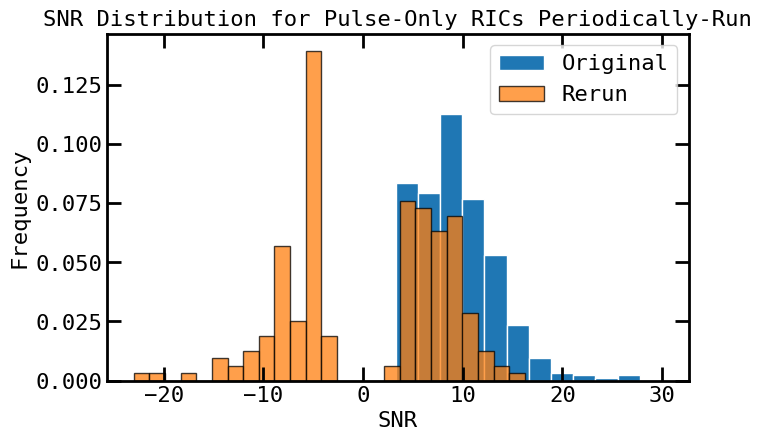

In [52]:
alldf =  pd.read_csv(pipe.datadir('output/bls.csv'))

fig, ax = pipe.setupPlot((7.5, 4.5), logscale=0)
ax.hist(alldf.SNR, density=True, range=(np.min(alldf.SNR), 30), edgecolor='white', bins=12, label='Original')
ax.hist(bdf.SNR, density=True, alpha=0.75, edgecolor='black', bins=25, label='Rerun')
ax.legend()
ax.set_xlabel('SNR')
ax.set_ylabel('Frequency')
ax.set_title('SNR Distribution for Pulse-Only RICs Periodically-Run', fontsize=16)
fig.show()

In [113]:
cols = ['RunNum', 'Pulses', 'Periodic', 'PulseFirst', 'PeriodicFirst']
def runstats(gp):
    arr = np.array(gp.RawPer != 0, dtype=int)
    return pd.Series([len(gp), np.sum(gp.RawPer == 0), np.sum(gp.RawPer > 0), \
                     np.all(np.diff(arr) >= 0), np.all(np.diff(arr) <= 0)])
rsdf = alldf.groupby('RIC')[alldf.columns].apply(runstats)
rsdf.rename(columns=dict(zip(rsdf.columns, cols)), inplace=True)
rsdf.head()

,RunNum,Pulses,Periodic,PulseFirst,PeriodicFirst
RIC,,,,,
434,2,0,2,True,True
518,2,1,1,False,True
541,10,10,0,True,True
566,1,1,0,True,True
2103,1,0,1,True,True


In [112]:
checkric = rsdf[np.logical_and(~rsdf.PulseFirst, ~rsdf.PeriodicFirst)].index
alldf[np.isin(alldf, checkric)]

,RIC,Period,T0,TDur,TDepth,RawPer,SR,Power,SNR,Time
155,4548611,70.060965,42.107639,0.048611,0.055781,0.000000,NaN,8.491695,8.491695,10.544328
156,4548611,27.127696,15.528728,0.189894,0.029567,27.127696,NaN,13.744960,9.877232,10.687886
157,4548611,1.180274,1.137628,0.099733,0.005517,1.180274,NaN,7.301272,8.896734,11.166044
158,4548611,70.175548,64.076389,0.125000,0.016831,0.000000,NaN,4.041426,4.041426,10.097283
241,286618,156.571270,56.250000,0.500000,0.018322,0.000000,NaN,10.813260,10.813260,8.152219
242,286618,1.365777,0.830844,0.206915,0.011813,1.364310,NaN,38.064709,36.214365,7.885967
243,286618,156.571270,32.298611,0.500000,0.014631,0.000000,NaN,9.258321,9.258321,6.849530
244,286618,70.252692,45.635417,0.256944,0.020053,0.000000,NaN,9.160328,9.160328,6.590895
245,286618,70.252692,45.635417,0.256944,0.020044,0.000000,NaN,9.146784,9.146784,6.891804
246,286618,70.252692,45.635417,0.256944,0.020044,0.000000,NaN,9.146784,9.146784,6.775823


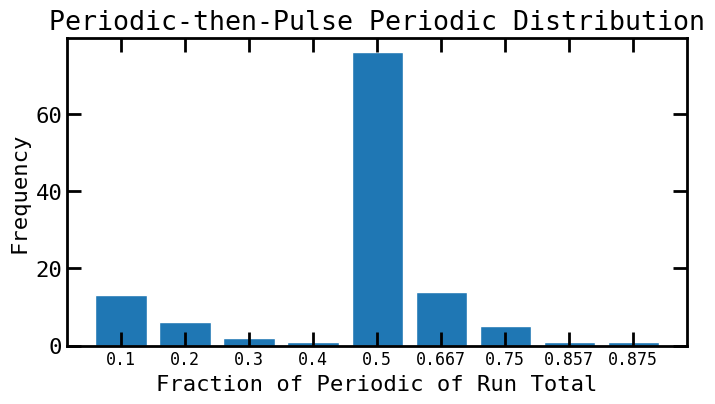

In [132]:
perfdf = rsdf[np.logical_and(~rsdf.PulseFirst, rsdf.PeriodicFirst)]
label, counts = np.unique(perfdf.Periodic/perfdf.RunNum, return_counts=True)
label = np.round(label, 3)

fig, ax = pipe.setupPlot((8, 4), logscale=0)
ax.bar(np.arange(0, len(label)), counts, edgecolor='white')
ax.set_xticks(np.arange(0, len(label)), label, fontsize=12)
ax.set_ylabel('Frequency')
ax.set_xlabel('Fraction of Periodic of Run Total')
ax.set_title('Periodic-then-Pulse Periodic Distribution')
fig.show()

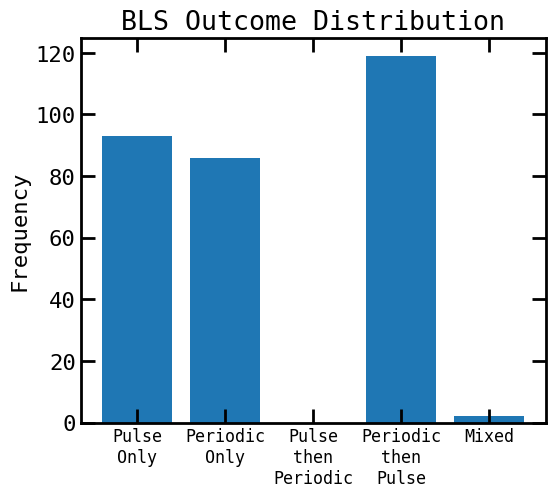

In [133]:
barlabels = [f'Pulse\nOnly', f'Periodic\nOnly', f'Pulse\nthen\nPeriodic', f'Periodic\nthen\nPulse', 'Mixed']
barC = [np.sum(rsdf.RunNum == rsdf.Pulses), np.sum(rsdf.RunNum == rsdf.Periodic), \
        np.sum(np.logical_and(rsdf.PulseFirst, ~rsdf.PeriodicFirst)), \
        np.sum(np.logical_and(~rsdf.PulseFirst, rsdf.PeriodicFirst)), np.sum(np.logical_and(~rsdf.PulseFirst, ~rsdf.PeriodicFirst))]

fig, ax = pipe.setupPlot((6, 5), logscale=0)
ax.bar(barlabels, barC, label=barlabels)
ax.set_xticks(barlabels, barlabels, fontsize=12)
ax.set_ylabel('Frequency')
ax.set_title('BLS Outcome Distribution')
fig.show()

maybe try to separate out the periodic search and the pulse search, so the snr comparison of pulse versus periodic signal, which depends on whether or not the duration is correct. the growing and shrinking pulse is probably better at finding the duration, the noise floor for the pulse is probably lower than for the periodic signal, so default to the pulse when the periodic signal is not strong enough.

at high snr, are we confused between pulse and periodic signal - using a shape that doesn't match well.
as we approach the noise floor, returning a spectrum, is the noise floor for a pulse floor different than for a periodic search? 
might be useful to see how both perform at these two extremes. 
negative snr means that the transit went the other way, telling us about the noise properties instead!